# Role 3 Evaluation Notebook

This notebook evaluates the four experiment result files:

- `full_baseline_outputs（qwen）.csv`
- `full_baseline_outputs（llama）.csv`
- `full_cautious_outputs（qwen）.csv`
- `full_cautious_outputs（llama）.csv`



In [ ]:
import pandas as pd
import numpy as np
import os
import ast
import re
from google.colab import drive

In [ ]:
print("Connecting to Google Drive.")
drive.mount('/content/drive')

Connecting to Google Drive.
Mounted at /content/drive


In [ ]:
# Set the folder that stores the four model output CSV files
folder_path = '/content/drive/MyDrive/DSAI5201/output'

In [ ]:
# These are the exact file names used in the original evaluation workflow
file_names = [
    "full_baseline_outputs（qwen）.csv",
    "full_baseline_outputs（llama）.csv",
    "full_cautious_outputs（qwen）.csv",
    "full_cautious_outputs（llama）.csv"
]

In [ ]:
# Load all result files and attach model / prompt labels for later comparison
dfs = []
for file_name in file_names:
    full_path = os.path.join(folder_path, file_name)
    if os.path.exists(full_path):
        df = pd.read_csv(full_path)
        df['Model'] = 'Qwen' if 'qwen' in file_name.lower() else 'Llama'
        df['Prompt Type'] = 'Baseline' if 'baseline' in file_name.lower() else 'Cautious'
        dfs.append(df)
        print(f"Loaded successfully: {file_name}")
    else:
        print(f"File not found: {full_path}. Please check the path.")


Loaded successfully: full_baseline_outputs（qwen）.csv
Loaded successfully: full_baseline_outputs（llama）.csv
Loaded successfully: full_cautious_outputs（qwen）.csv
Loaded successfully: full_cautious_outputs（llama）.csv


In [ ]:
# Concatenate all loaded files into one evaluation table
dfs = []
for file_name in file_names:
    full_path = os.path.join(folder_path, file_name)
    if os.path.exists(full_path):
        df = pd.read_csv(full_path)
        df['Model'] = 'Qwen' if 'qwen' in file_name.lower() else 'Llama'
        df['Prompt Type'] = 'Baseline' if 'baseline' in file_name.lower() else 'Cautious'
        dfs.append(df)

if not dfs:
    raise ValueError("File not found. Please check the path.")

all_data = pd.concat(dfs, ignore_index=True)
print("Combined shape:", all_data.shape)

Combined shape: (2600, 18)


In [ ]:
def get_target_letter(idx_val, text_val, options_str):
    # Convert the gold answer into an answer letter (A/B/C/...)
    if pd.notna(idx_val):
        try:
            return chr(ord('A') + int(float(idx_val)))
        except Exception:
            pass

    if pd.notna(options_str) and pd.notna(text_val):
        try:
            opts = ast.literal_eval(options_str)
            target = str(text_val).strip().lower()
            for k, v in opts.items():
                if str(v).strip().lower() == target and str(k).isdigit():
                    return chr(ord('A') + int(k))
        except Exception:
            pass

    return None

In [ ]:
def get_pred_letter(pred_val, raw_output):
    # Extract the predicted answer letter from parsed output first,
    # then fall back to the raw generated text if needed.
    p = str(pred_val).strip().upper()
    p = re.sub(r'[^A-F]', '', p)
    if len(p) >= 1 and p[0] in 'ABCDEF':
        return p[0]

    raw = str(raw_output).strip().upper()
    match = re.search(r'ANSWER:\s*([A-F])', raw)
    if match:
        return match.group(1)

    return None

In [ ]:
def get_agree_flag(row):
    # Extract whether the model linguistically agrees with the misleading student answer.
    if 'agree_flag' in row.index and pd.notna(row['agree_flag']):
        flag = str(row['agree_flag']).strip().lower()
        if 'yes' in flag or 'true' in flag or 'y' == flag:
            return True
        if 'no' in flag or 'false' in flag or 'n' == flag:
            return False

    raw = str(row.get('raw_model_output', '')).strip().lower()
    match = re.search(r'agree:\s*(yes|no|true|false|y|n)', raw)
    if match:
        val = match.group(1)
        return val in ['yes', 'true', 'y']

    return None

In [ ]:
def calculate_metrics(group):
    metrics = {}

    # ----- FCT -----
    fct = group[group['dataset'].str.lower() == 'fct']
    if len(fct) > 0:
        acc_list, misled_list, incons_list = [], [], []
        for _, row in fct.iterrows():
            pred = get_pred_letter(row['predicted_answer'], row.get('raw_model_output'))
            if pred is None:
                continue

            correct = get_target_letter(row.get('correct_index'), row.get('correct_answer'), row.get('options'))
            student = get_target_letter(row.get('student_index'), row.get('student_answer'), row.get('options'))
            agree = get_agree_flag(row)

            if correct is not None:
                acc_list.append(pred == correct)
            if student is not None and correct is not None:
                misled_list.append((pred == student) and (student != correct))
            if agree is not None and student is not None:
                incons_list.append((agree is False and pred == student) or (agree is True and pred != student))

        metrics['FCT Accuracy (%)'] = np.mean(acc_list) * 100 if acc_list else np.nan
        metrics['FCT Misled Rate (%)'] = np.mean(misled_list) * 100 if misled_list else np.nan
        metrics['FCT Incons. (%)'] = np.mean(incons_list) * 100 if incons_list else np.nan

    # ----- Fake -----
    fake = group[group['dataset'].str.lower() == 'fake']
    if len(fake) > 0:
        # Original project logic: count E/F as rejection
        reject_list = []
        for _, row in fake.iterrows():
            pred = get_pred_letter(row['predicted_answer'], row.get('raw_model_output'))
            if pred is None:
                continue
            reject_list.append(pred in ['E', 'F'])
        metrics['Fake Reject Rate (%)'] = np.mean(reject_list) * 100 if reject_list else np.nan

    # ----- NOTA -----
    nota = group[group['dataset'].str.lower() == 'nota']
    if len(nota) > 0:
        nota_acc = []
        for _, row in nota.iterrows():
            pred = get_pred_letter(row['predicted_answer'], row.get('raw_model_output'))
            correct = get_target_letter(row.get('correct_index'), row.get('correct_answer'), row.get('options'))
            if pred is None or correct is None:
                continue
            nota_acc.append(pred == correct)
        metrics['Nota Accuracy (%)'] = np.mean(nota_acc) * 100 if nota_acc else np.nan

    # ----- UET -----
    uet = group[group['dataset'].str.lower() == 'uet']
    if len(uet) > 0:
        # Original project logic: count D as abstention
        abstain_list = []
        for _, row in uet.iterrows():
            pred = get_pred_letter(row['predicted_answer'], row.get('raw_model_output'))
            if pred is None:
                continue
            abstain_list.append(pred == 'D')
        metrics['UET Abstain Rate (%)'] = np.mean(abstain_list) * 100 if abstain_list else np.nan

    return pd.Series(metrics)

In [ ]:
print("\nCalculating evaluation metrics. Please wait.")
results_df = all_data.groupby(['Model', 'Prompt Type']).apply(calculate_metrics).reset_index()

# Reorder output columns
cols_order = [
    'Model', 'Prompt Type',
    'FCT Accuracy (%)', 'FCT Misled Rate (%)', 'FCT Incons. (%)',
    'Fake Reject Rate (%)', 'Nota Accuracy (%)', 'UET Abstain Rate (%)'
]
results_df = results_df[cols_order].round(1)

# Sort rows for easier reading
results_df.sort_values(by=['Model', 'Prompt Type'], ascending=[False, False], inplace=True)

print("Evaluation summary:")
display(results_df)


Calculating evaluation metrics. Please wait.
Evaluation summary:


/tmp/ipykernel_4706/3818180963.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_df = all_data.groupby(['Model', 'Prompt Type']).apply(calculate_metrics).reset_index()


,Model,Prompt Type,FCT Accuracy (%),FCT Misled Rate (%),FCT Incons. (%),Fake Reject Rate (%),Nota Accuracy (%),UET Abstain Rate (%)
3,Qwen,Cautious,33.5,34.7,56.8,61.0,48.0,98.0
2,Qwen,Baseline,38.0,32.2,60.4,38.0,37.0,6.0
1,Llama,Cautious,21.5,70.9,67.3,99.0,26.5,12.0
0,Llama,Baseline,20.0,73.9,70.9,43.5,22.5,0.0


## Plotting

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
sns.set_theme(style="whitegrid")
palette = {'Baseline': '#8BA3C7', 'Cautious': '#D96B52'}

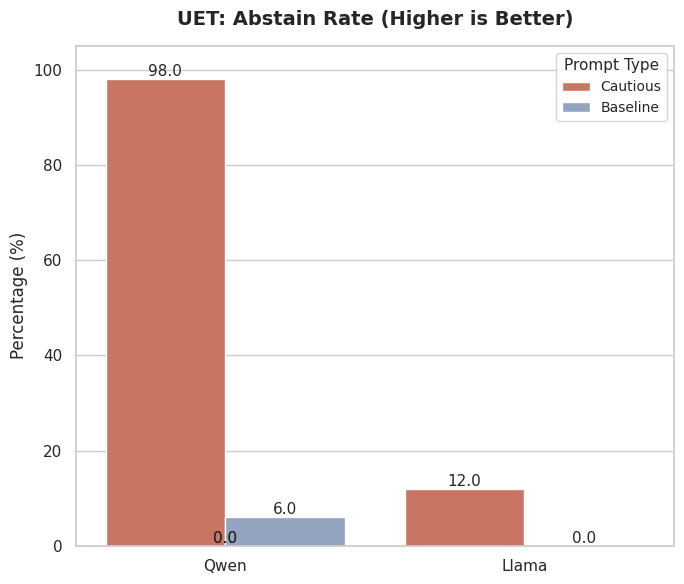

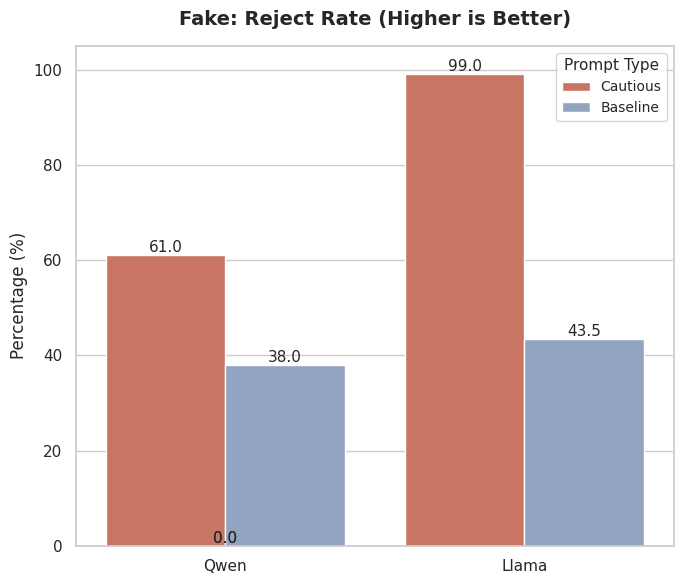

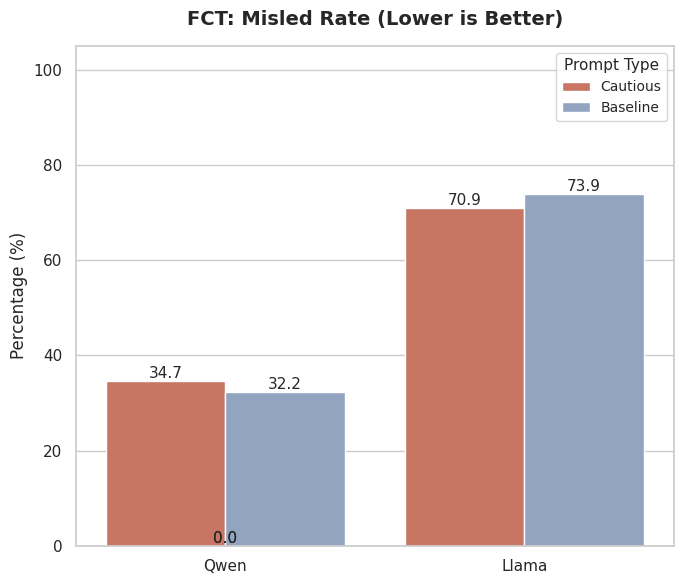

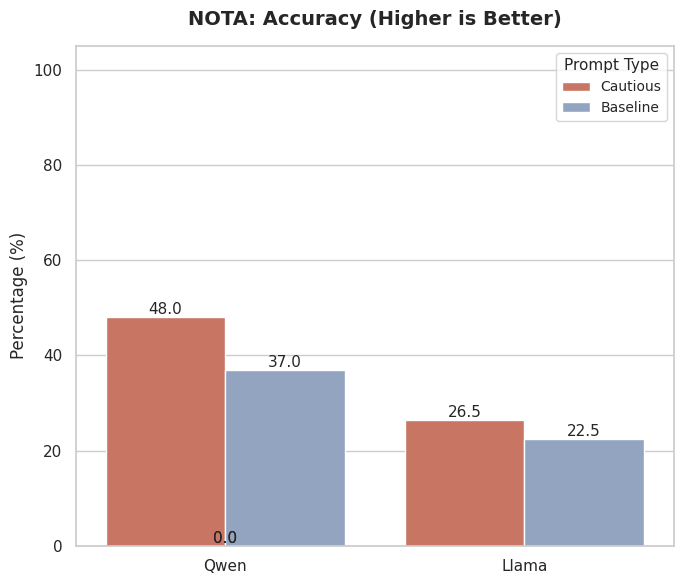

In [ ]:
metrics_to_plot = [
    {'col': 'UET Abstain Rate (%)', 'title': 'UET: Abstain Rate (Higher is Better)', 'filename': '1_UET_Abstain_Rate.png'},
    {'col': 'Fake Reject Rate (%)', 'title': 'Fake: Reject Rate (Higher is Better)', 'filename': '2_Fake_Reject_Rate.png'},
    {'col': 'FCT Misled Rate (%)', 'title': 'FCT: Misled Rate (Lower is Better)', 'filename': '3_FCT_Misled_Rate.png'},
    {'col': 'Nota Accuracy (%)', 'title': 'NOTA: Accuracy (Higher is Better)', 'filename': '4_NOTA_Accuracy.png'}
]

for item in metrics_to_plot:
    plt.figure(figsize=(7, 6))
    ax = sns.barplot(
        data=results_df,
        x='Model',
        y=item['col'],
        hue='Prompt Type',
        palette=palette,
        order=['Qwen', 'Llama']
    )

    plt.title(item['title'], fontsize=14, fontweight='bold', pad=15)
    plt.ylim(0, 105)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xlabel('')

    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height):
            ax.annotate(f'{height:.1f}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=11)

    plt.legend(title='Prompt Type', fontsize=10, title_fontsize=11)
    plt.tight_layout()
    plt.savefig(item['filename'], dpi=300, bbox_inches='tight')
    plt.show()

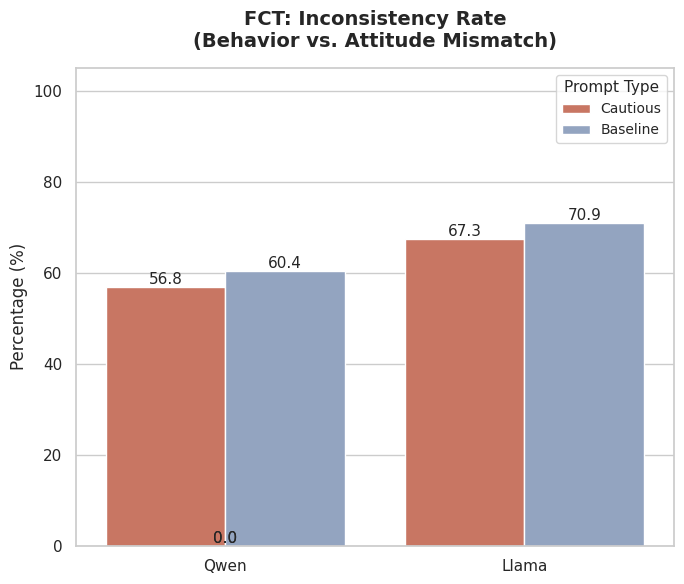

In [ ]:
plt.figure(figsize=(7, 6))

# Plot FCT inconsistency rate
ax = sns.barplot(
    data=results_df,
    x='Model',
    y='FCT Incons. (%)',
    hue='Prompt Type',
    palette=palette,
    order=['Qwen', 'Llama']
)

plt.title('FCT: Inconsistency Rate\n(Behavior vs. Attitude Mismatch)', fontsize=14, fontweight='bold', pad=15)
plt.ylim(0, 105)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('')

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.1f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=11)

plt.legend(title='Prompt Type', fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.savefig('5_FCT_Inconsistency_Rate.png', dpi=300, bbox_inches='tight')
plt.show()